In [1]:
import os
import csv
import time
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple
import json

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn

print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
seed_everything(RANDOM_STATE)

FAST_MODE = False  
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

torch: 2.11.0
device: cpu


In [2]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 3
    person_only: bool = True  

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=False, n_show=3, person_only=True)

In [3]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [4]:
STL10_MEAN = (0.485, 0.456, 0.406)
STL10_STD  = (0.229, 0.224, 0.225)

tf_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

tf_train_aug = transforms.Compose([
    transforms.RandomCrop(96, padding=12),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

ds_train_full = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', download=True, transform=tf_base
)
ds_train_aug = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', transform=tf_train_aug, download=True
)
ds_test = torchvision.datasets.STL10(
    root=DATA_DIR, split='test', download=True, transform=tf_base
)

class_names = ds_train_full.classes
NUM_CLASSES = len(class_names)

print(f"Train full: {len(ds_train_full)}")
print(f"Test: {len(ds_test)}")
print(f"Classes: {class_names}")

Train full: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    if fast_mode:
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test)


batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

/Users/apple/Desktop/aie4/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


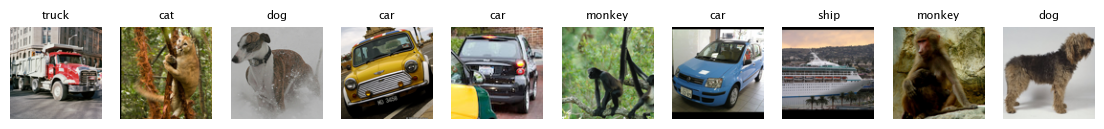

In [6]:
def denorm_stl(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    return plt

imgs = show_images(train_loader)
imgs.savefig("artifacts/figures/augmentations_preview.png")
imgs.show()

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
    
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 4814666


In [8]:
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [9]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history
def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [10]:
criterion = nn.CrossEntropyLoss()

def run_experiment(
    exp_id: str,
    train_loader,
    val_loader,
    model: nn.Module,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    epochs: int = EPOCHS
):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}


Experiment C1 (simple-cnn-base) | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666
Epoch 01/12 | train loss 1.8810, acc 0.324 | val loss 1.6454, acc 0.350 | 43.3s
Epoch 02/12 | train loss 1.4166, acc 0.473 | val loss 1.4294, acc 0.485 | 42.3s
Epoch 03/12 | train loss 1.1582, acc 0.596 | val loss 1.3887, acc 0.514 | 40.9s
Epoch 04/12 | train loss 0.9783, acc 0.647 | val loss 1.3759, acc 0.511 | 39.4s
Epoch 05/12 | train loss 0.8043, acc 0.723 | val loss 1.2776, acc 0.571 | 40.9s
Epoch 06/12 | train loss 0.5527, acc 0.815 | val loss 1.4883, acc 0.556 | 41.9s
Epoch 07/12 | train loss 0.3575, acc 0.877 | val loss 1.5579, acc 0.576 | 41.0s
Epoch 08/12 | train loss 0.2480, acc 0.921 | val loss 1.6812, acc 0.595 | 40.1s
Epoch 09/12 | train loss 0.1398, acc 0.958 | val loss 2.0288, acc 0.571 | 42.9s
Epoch 10/12 | train loss 0.0811, acc 0.981 | val loss 2.0725, acc 0.593 | 41.3s
Epoch 11/12 | train loss 0.0435, acc 0.990 | val loss 2.2172, acc 0.587 | 41.7s
Epoch 12/12 | train los

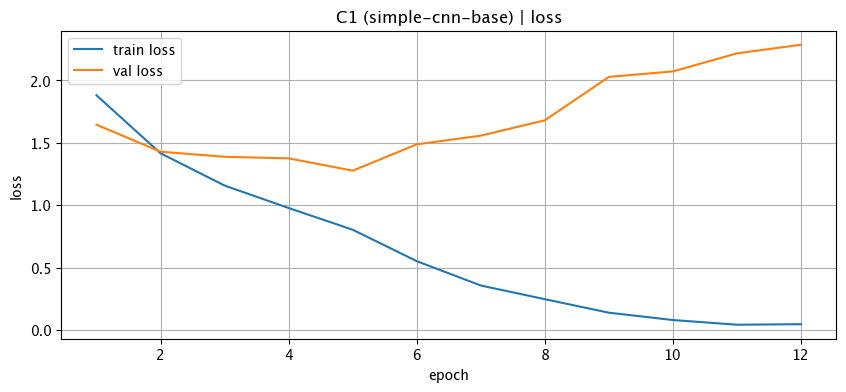

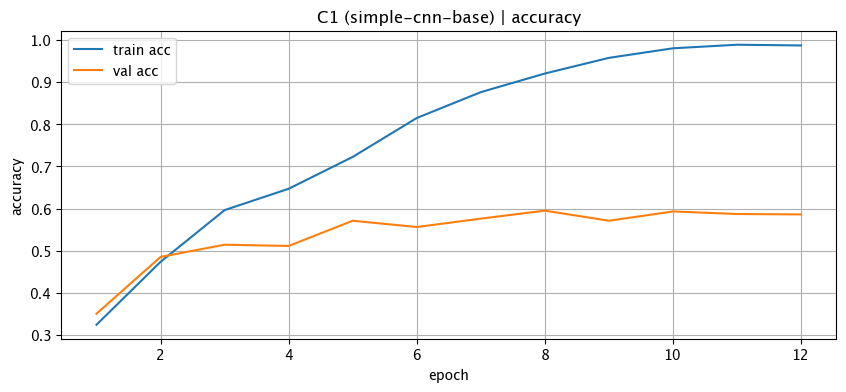

In [11]:
title = "C1 (simple-cnn-base)"

res_c1 = run_experiment(
    title,
    train_loader,
    val_loader,
    SimpleCNN(NUM_CLASSES)
)

plot_history(res_c1["history"], title=title)

In [12]:
n_val = int(len(ds_train_full) * 0.2)
n_train = len(ds_train_full) - n_val

ds_train_base, ds_val_base = random_split(
    ds_train_full, 
    [n_train, n_val], 
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

train_loader_aug = DataLoader(
    Subset(ds_train_aug, ds_train_base.indices), 
    batch_size=BATCH_SIZE, 
    shuffle=True
)
val_loader_aug = val_loader 



Experiment C2 (simple-cnn-aug) | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666
Epoch 01/12 | train loss 2.1099, acc 0.218 | val loss 1.8571, acc 0.285 | 29.8s
Epoch 02/12 | train loss 1.7797, acc 0.333 | val loss 1.6561, acc 0.365 | 29.3s
Epoch 03/12 | train loss 1.6086, acc 0.394 | val loss 1.4636, acc 0.477 | 29.0s
Epoch 04/12 | train loss 1.5030, acc 0.435 | val loss 1.3903, acc 0.471 | 28.8s
Epoch 05/12 | train loss 1.4497, acc 0.453 | val loss 1.3135, acc 0.504 | 29.7s
Epoch 06/12 | train loss 1.3684, acc 0.484 | val loss 1.3236, acc 0.495 | 29.6s
Epoch 07/12 | train loss 1.3222, acc 0.516 | val loss 1.3105, acc 0.498 | 29.5s
Epoch 08/12 | train loss 1.2977, acc 0.527 | val loss 1.3058, acc 0.508 | 30.4s
Epoch 09/12 | train loss 1.2651, acc 0.526 | val loss 1.1802, acc 0.580 | 31.3s
Epoch 10/12 | train loss 1.2358, acc 0.550 | val loss 1.3271, acc 0.504 | 30.9s
Epoch 11/12 | train loss 1.1805, acc 0.568 | val loss 1.1760, acc 0.563 | 29.0s
Epoch 12/12 | train loss

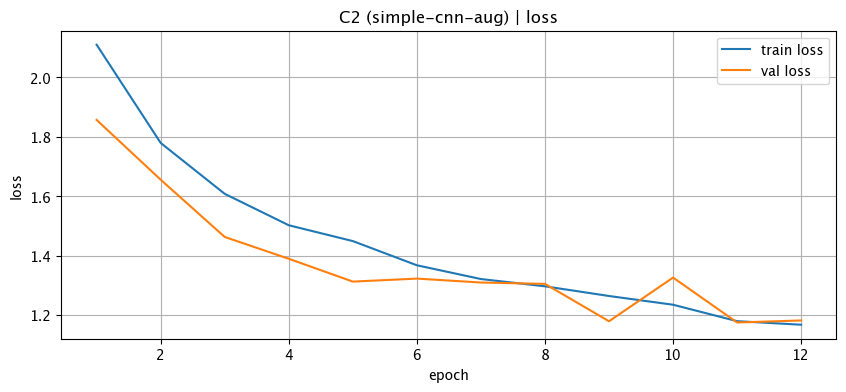

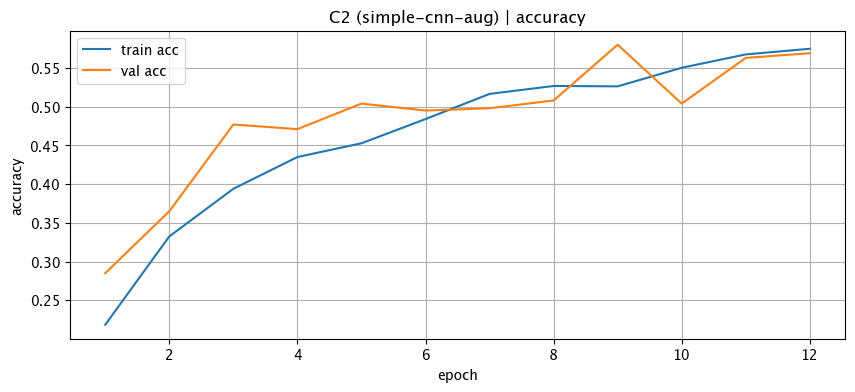

In [13]:
title = "C2 (simple-cnn-aug)"

res_c2 = run_experiment(
    title, 
    train_loader_aug,
    val_loader_aug,
    SimpleCNN(NUM_CLASSES), 
)

plot_history(res_c2["history"], title=title)

In [14]:
def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [15]:
weights = ResNet18_Weights.IMAGENET1K_V1
tf_resnet_base = weights.transforms() 


ds_train_full_resnet = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', download=False, transform=tf_resnet_base
)
ds_test_resnet = torchvision.datasets.STL10(
    root=DATA_DIR, split='test', download=False, transform=tf_resnet_base
)

n_total = len(ds_train_full_resnet)
n_val = int(n_total * 0.2)
n_train = n_total - n_val

ds_train_base_resnet, ds_val_base_resnet = random_split(
    ds_train_full_resnet, [n_train, n_val], 
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

train_loader_resnet = DataLoader(ds_train_base_resnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_resnet = DataLoader(ds_val_base_resnet, batch_size=BATCH_SIZE, shuffle=False)

print("train:", len(train_loader_resnet.dataset))
print("val:", len(val_loader_resnet.dataset))

train: 4000
val: 1000


Trainable params: 5130

Experiment C3 (ResNet18-Head-Only) | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 5130
Epoch 01/12 | train loss 1.4275, acc 0.609 | val loss 0.7289, acc 0.871 | 120.2s
Epoch 02/12 | train loss 0.5217, acc 0.908 | val loss 0.4213, acc 0.910 | 112.2s
Epoch 03/12 | train loss 0.3476, acc 0.928 | val loss 0.3364, acc 0.920 | 111.4s
Epoch 04/12 | train loss 0.2792, acc 0.941 | val loss 0.2919, acc 0.925 | 117.1s
Epoch 05/12 | train loss 0.2407, acc 0.946 | val loss 0.2689, acc 0.928 | 118.7s
Epoch 06/12 | train loss 0.2164, acc 0.947 | val loss 0.2557, acc 0.924 | 116.0s
Epoch 07/12 | train loss 0.2046, acc 0.951 | val loss 0.2451, acc 0.925 | 117.1s
Epoch 08/12 | train loss 0.1809, acc 0.955 | val loss 0.2353, acc 0.929 | 118.4s
Epoch 09/12 | train loss 0.1680, acc 0.961 | val loss 0.2265, acc 0.927 | 120.1s
Epoch 10/12 | train loss 0.1586, acc 0.960 | val loss 0.2226, acc 0.929 | 118.6s
Epoch 11/12 | train loss 0.1518, acc 0.962 | val loss 0.2158, acc 0.93

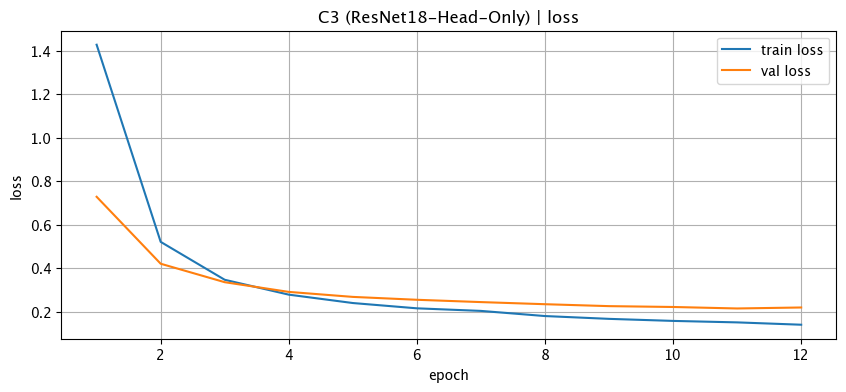

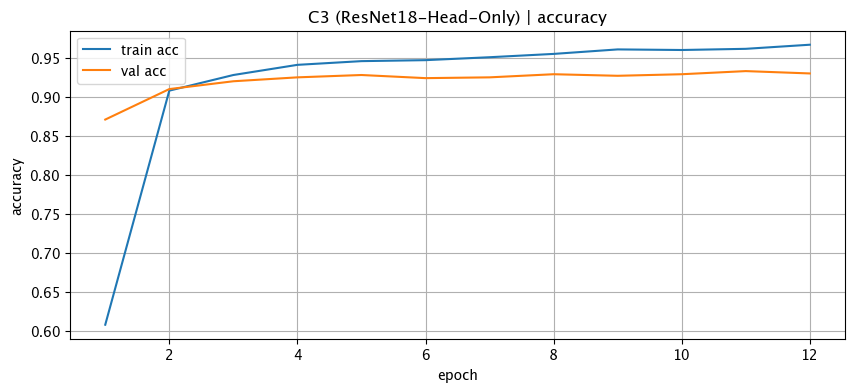

In [17]:
title = "C3 (ResNet18-Head-Only)"

def get_resnet18_head_only(num_classes=10):
    model = resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
        
    print(f"Trainable params: {count_params(model)}")
    return model


res_c3 = run_experiment(
    title,  
    train_loader_resnet, 
    val_loader_resnet,
    get_resnet18_head_only(),
    lr=1e-3,
    weight_decay=0.0
)

title = "C3 (ResNet18-Head-Only)"
plot_history(res_c3["history"], title)

Trainable params: 8398858
Trainable params: 8398858

Experiment C4 (ResNet18-FineTune) | lr=0.0001 weight_decay=0.0001 epochs=12
Trainable params: 8398858
Epoch 01/12 | train loss 0.8290, acc 0.779 | val loss 0.3127, acc 0.918 | 137.5s
Epoch 02/12 | train loss 0.1716, acc 0.965 | val loss 0.2307, acc 0.936 | 154.1s
Epoch 03/12 | train loss 0.0751, acc 0.994 | val loss 0.2074, acc 0.943 | 156.9s
Epoch 04/12 | train loss 0.0355, acc 0.999 | val loss 0.2029, acc 0.942 | 139.8s
Epoch 05/12 | train loss 0.0199, acc 1.000 | val loss 0.1960, acc 0.941 | 151.0s
Epoch 06/12 | train loss 0.0141, acc 1.000 | val loss 0.1924, acc 0.946 | 142.3s
Epoch 07/12 | train loss 0.0099, acc 1.000 | val loss 0.1940, acc 0.945 | 139.0s
Epoch 08/12 | train loss 0.0076, acc 1.000 | val loss 0.1944, acc 0.945 | 139.4s
Epoch 09/12 | train loss 0.0060, acc 1.000 | val loss 0.1948, acc 0.944 | 141.9s
Epoch 10/12 | train loss 0.0048, acc 1.000 | val loss 0.1949, acc 0.945 | 142.8s
Epoch 11/12 | train loss 0.0040, ac

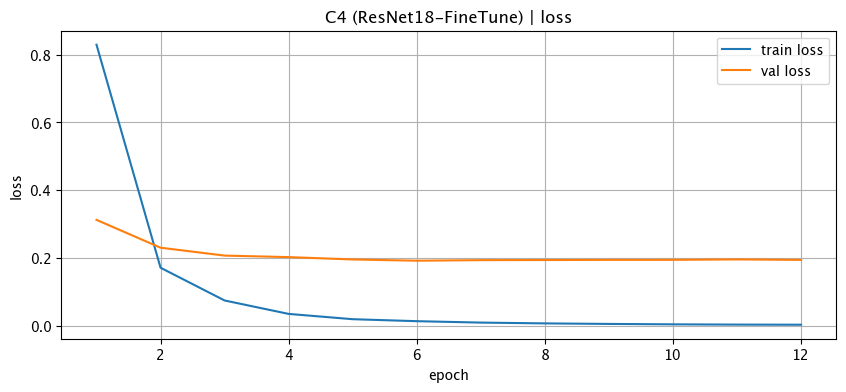

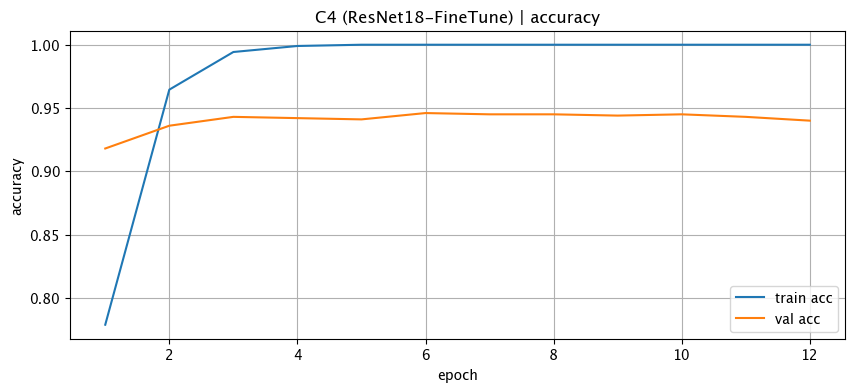

In [19]:
title = "C4 (ResNet18-FineTune)"

def get_resnet18_finetune(num_classes=10):
    model = resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.layer4.parameters():  
        param.requires_grad = True
    for param in model.fc.parameters():    
        param.requires_grad = True
    
    print(f"Trainable params: {count_params(model)}")  
    return model


model_c4 = get_resnet18_finetune()
res_c4 = run_experiment(
    title,
    train_loader_resnet, 
    val_loader_resnet, 
    get_resnet18_finetune(),
    lr=1e-4,  
    weight_decay=1e-4
)

plot_history(res_c4["history"], title)

In [20]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc_c1 = accuracy_on_loader(res_c1["model"], test_loader)
test_acc_c2 = accuracy_on_loader(res_c2["model"], test_loader)
test_acc_c3 = accuracy_on_loader(res_c3["model"], test_loader)
test_acc_c4 = accuracy_on_loader(res_c4["model"], test_loader)

print("Test acc (CNN):", round(test_acc_c1, 4))
print("Test acc (CNN + aug):", round(test_acc_c2, 4))
print("Test acc (ResNet + HeadOnly):", round(test_acc_c3, 4))
print("Test acc (ResNet + FineTune):", round(test_acc_c4, 4))

Test acc (CNN): 0.5743
Test acc (CNN + aug): 0.5716
Test acc (ResNet + HeadOnly): 0.6379
Test acc (ResNet + FineTune): 0.6494


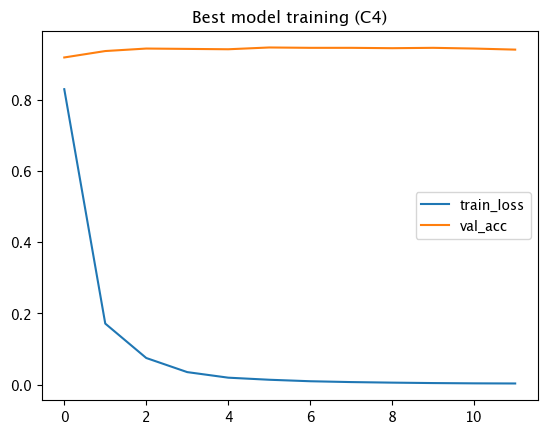

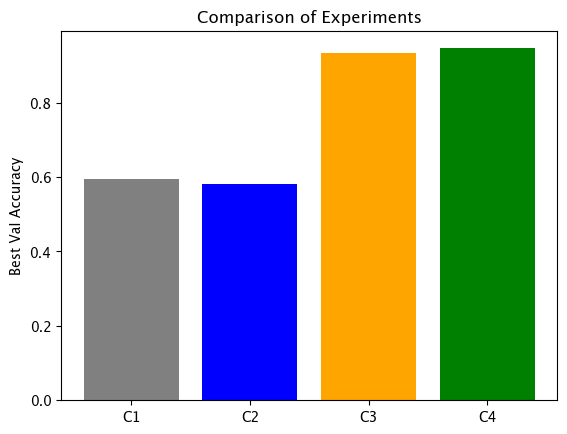

In [21]:
c1_val = res_c1["best_val_acc"]
c2_val = res_c2["best_val_acc"]
c3_val = res_c3["best_val_acc"]
c4_val = res_c4["best_val_acc"]

best_res = res_c4
history = best_res["history"]
test_acc = test_acc_c4

torch.save(best_res["model"].state_dict(), "artifacts/best_classifier.pt")

plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.title("Best model training (C4)")
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show() 

plt.figure()
vals = [c1_val, c2_val, c3_val, c4_val]
names = ["C1","C2","C3","C4"]
plt.bar(names, vals, color=['gray', 'blue', 'orange', 'green'])
plt.title("Comparison of Experiments")
plt.ylabel("Best Val Accuracy")
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

best_config = {
    "experiment_id": "C4", 
    "dataset": "STL10", 
    "seed": 42,
    "architecture": "ResNet18 (pretrained) -> partial finetune (layer4 + fc)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": EPOCHS,  
    "train_transforms": "Resize -> ToTensor",
    "val_transforms": "Resize -> ToTensor",
    "augmentations": "RandomHorizontalFlip, RandomCrop",
    "best_val_accuracy": float(c4_val),
    "test_accuracy": float(test_acc)
}

with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

Пункт B Detection

In [22]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.6          # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=False, n_show=4, score_thr=0.6, iou_thr=0.5, model_name='fasterrcnn_mobilenet_v3_large_fpn')

In [23]:
from torchvision.datasets import VOCDetection
class VOCDetectionDataset(Dataset):
    def __init__(self, root):
        self.dataset = VOCDetection(root=root, year='2012', image_set='val', download=True)

        self.map = {
            'aeroplane': 'airplane', 'bicycle': 'bicycle', 'bird': 'bird',
            'boat': 'boat', 'bottle': 'bottle', 'bus': 'bus', 'car': 'car',
            'cat': 'cat', 'chair': 'chair', 'cow': 'cow',
            'diningtable': 'dining table', 'dog': 'dog', 'horse': 'horse',
            'motorbike': 'motorcycle', 'person': 'person',
            'pottedplant': 'potted plant', 'sheep': 'sheep',
            'sofa': 'couch', 'train': 'train', 'tvmonitor': 'tv'
        }

        self.coco = [
            '__background__','person','bicycle','car','motorcycle','airplane','bus',
            'train','truck','boat','traffic light','fire hydrant','stop sign',
            'parking meter','bench','bird','cat','dog','horse','sheep','cow',
            'elephant','bear','zebra','giraffe','backpack','umbrella','handbag',
            'tie','suitcase','frisbee','skis','snowboard','sports ball','kite',
            'baseball bat','baseball glove','skateboard','surfboard','tennis racket',
            'bottle','wine glass','cup','fork','knife','spoon','bowl','banana',
            'apple','sandwich','orange','broccoli','carrot','hot dog','pizza',
            'donut','cake','chair','couch','potted plant','bed','dining table',
            'toilet','tv','laptop','mouse','remote','keyboard','cell phone',
            'microwave','oven','toaster','sink','refrigerator','book','clock',
            'vase','scissors','teddy bear','hair drier','toothbrush'
        ]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, xml = self.dataset[idx]

        boxes, labels = [], []

        for obj in xml['annotation']['object']:
            b = obj['bndbox']
            name = self.map.get(obj['name'])

            if name in self.coco:
                boxes.append([
                    float(b['xmin']),
                    float(b['ymin']),
                    float(b['xmax']),
                    float(b['ymax'])
                ])
                labels.append(self.coco.index(name))

        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4))
        labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        img = F.pil_to_tensor(img).float()/255.0

        return img, {"boxes": boxes, "labels": labels}


dataset = VOCDetectionDataset('data')
loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: x)

In [26]:
model = fasterrcnn_resnet50_fpn(weights='DEFAULT').to(DEVICE)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [27]:
def iou(a,b):
    x1,y1 = max(a[0],b[0]), max(a[1],b[1])
    x2,y2 = min(a[2],b[2]), min(a[3],b[3])

    inter = max(0,x2-x1)*max(0,y2-y1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union else 0


def match(pb, pl, ps, gb, gl):
    used = [False]*len(gb)
    tp=fp=0
    ious=[]

    order = torch.argsort(ps, descending=True)

    for i in order:
        best, idx = 0, -1

        for j,(gbox,glabel) in enumerate(zip(gb,gl)):
            if used[j] or pl[i]!=glabel: continue
            val = iou(pb[i].cpu().numpy(), gbox.cpu().numpy())
            if val>best:
                best, idx = val, j

        if best>=0.5:
            tp+=1
            used[idx]=True
            ious.append(best)
        else:
            fp+=1

    fn = sum(not u for u in used)
    return tp,fp,fn,ious

In [28]:
def run(threshold, max_samples=300):
    tp = fp = fn = 0
    ious = []
    examples = []

    with torch.no_grad():
        for i, b in enumerate(loader):
            if i >= max_samples:
                break

            if i % 50 == 0:
                print(f"Processing {i}/{max_samples}")

            img, target = b[0]
            img = img.to(DEVICE)

            pred = model([img])[0]

            keep = pred['scores'] >= threshold

            pb = pred['boxes'][keep]
            pl = pred['labels'][keep]
            ps = pred['scores'][keep]

            tpp, fpp, fnn, ii = match(pb, pl, ps, target['boxes'], target['labels'])

            tp += tpp
            fp += fpp
            fn += fnn
            ious += ii

            if i < 4:
                examples.append((img.cpu(), target, pb.cpu(), ps.cpu()))

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    miou = float(np.mean(ious)) if ious else 0

    return {
        "precision": precision,
        "recall": recall,
        "mean_iou": miou,
        "tp": tp,
        "fp": fp,
        "fn": fn
    }, examples

m1, ex1 = run(0.3)
m2, ex2 = run(0.7)

print("V1:", m1)
print("V2:", m2)

Processing 0/300
Processing 50/300
Processing 100/300
Processing 150/300
Processing 200/300
Processing 250/300
Processing 0/300
Processing 50/300
Processing 100/300
Processing 150/300
Processing 200/300
Processing 250/300
V1: {'precision': 0.2105475040257649, 'recall': 0.6645489199491741, 'mean_iou': 0.8263781070709229, 'tp': 523, 'fp': 1961, 'fn': 264}
V2: {'precision': 0.41830624465355004, 'recall': 0.6213468869123253, 'mean_iou': 0.8326331377029419, 'tp': 489, 'fp': 680, 'fn': 298}


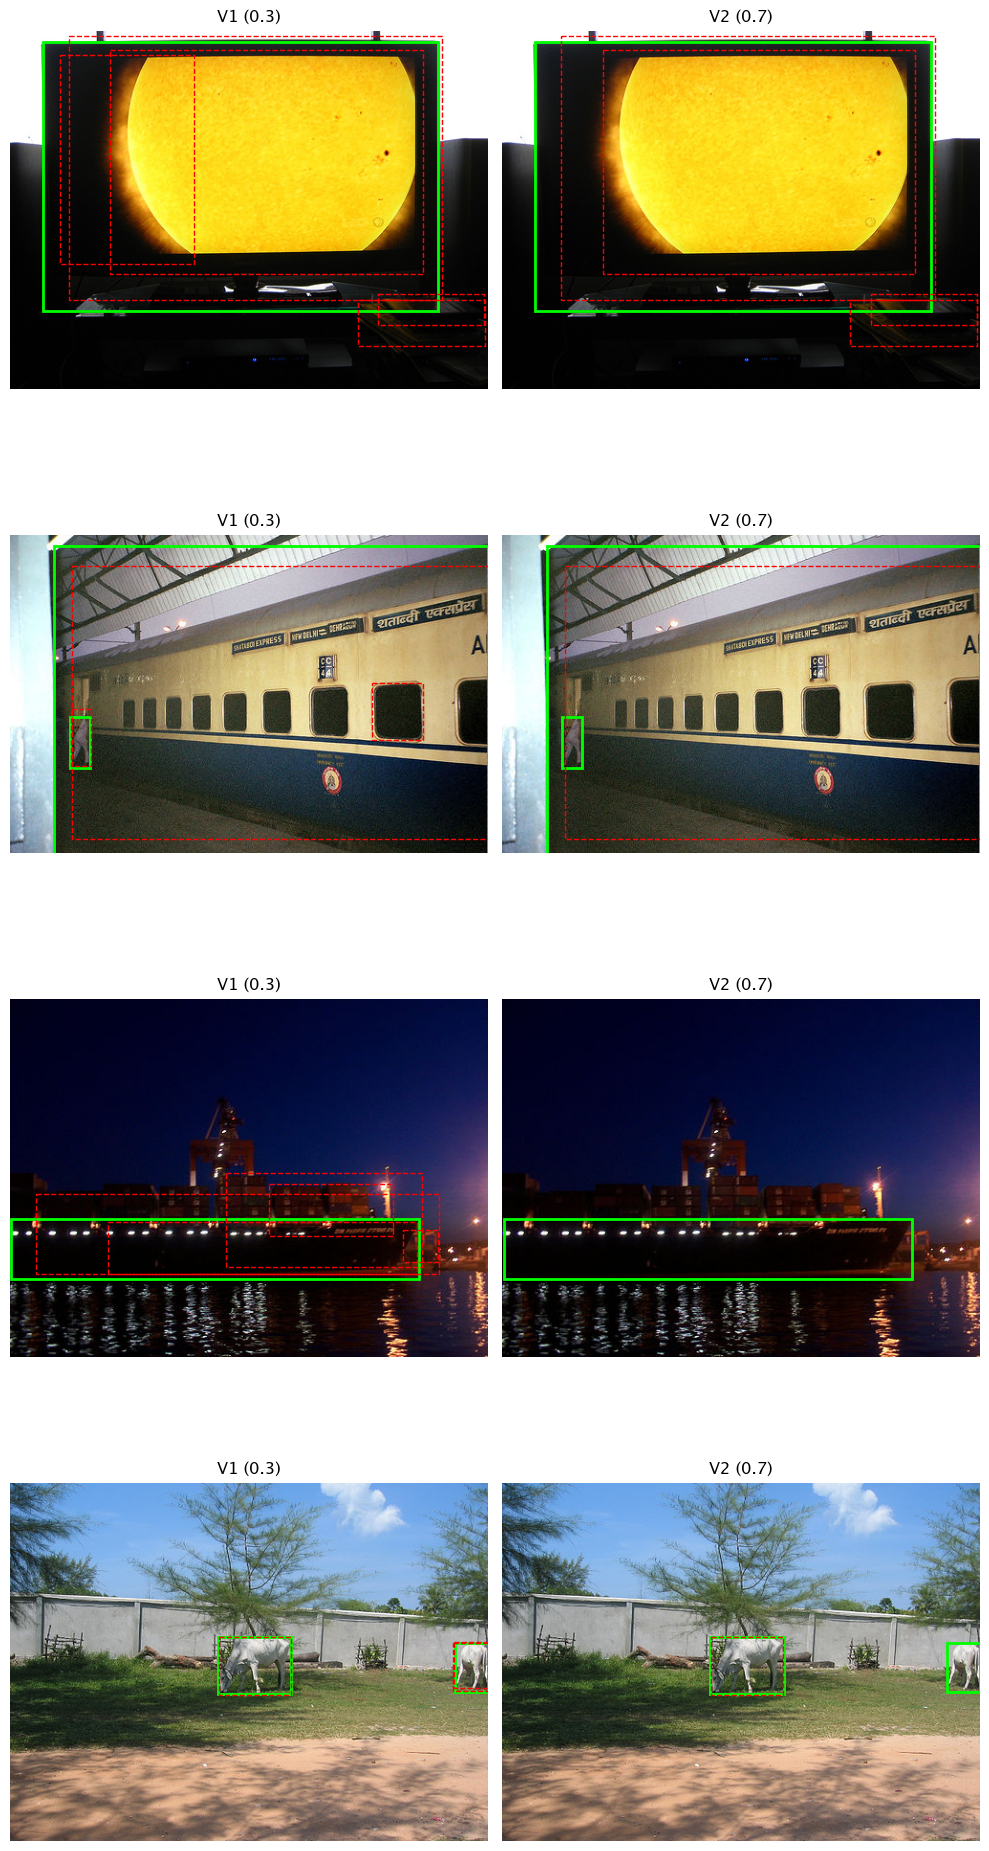

In [29]:
def draw(ax, img, gt, pb, ps):
    im = np.clip(img.permute(1,2,0).numpy(),0,1)
    ax.imshow(im)
    ax.axis('off')

    for b in gt['boxes']:
        b=b.numpy()
        ax.add_patch(patches.Rectangle((b[0],b[1]),b[2]-b[0],b[3]-b[1],
                                       edgecolor='lime',fill=False,linewidth=2))

    for b,s in zip(pb,ps):
        b=b.numpy()
        ax.add_patch(patches.Rectangle((b[0],b[1]),b[2]-b[0],b[3]-b[1],
                                       edgecolor='red',fill=False,linestyle='--'))

fig,ax = plt.subplots(4,2, figsize=(10,20))

for i in range(4):
    draw(ax[i,0], ex1[i][0], ex1[i][1], ex1[i][2], ex1[i][3])
    ax[i,0].set_title("V1 (0.3)")

    draw(ax[i,1], ex2[i][0], ex2[i][1], ex2[i][2], ex2[i][3])
    ax[i,1].set_title("V2 (0.7)")

plt.tight_layout()
plt.savefig("artifacts/figures/detection_examples.png", dpi=150)
plt.show()

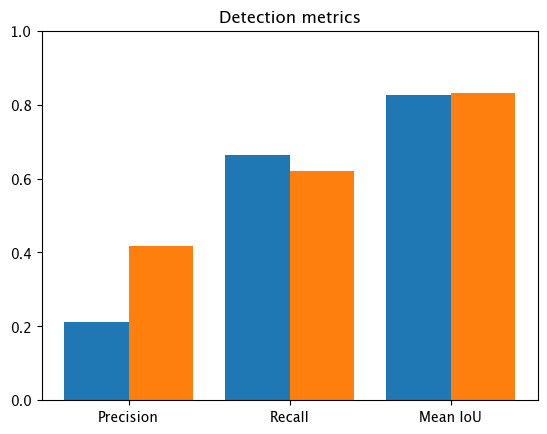

In [30]:
names = ["Precision","Recall","Mean IoU"]
v1 = [m1['precision'], m1['recall'], m1['mean_iou']]
v2 = [m2['precision'], m2['recall'], m2['mean_iou']]

plt.figure()
x = np.arange(3)
plt.bar(x-0.2,v1,0.4)
plt.bar(x+0.2,v2,0.4)
plt.xticks(x,names)
plt.ylim(0,1)
plt.title("Detection metrics")
plt.savefig("artifacts/figures/detection_metrics.png", dpi=150)
plt.show()

In [31]:
with open("artifacts/runs.csv", "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "experiment_id","task","dataset","seed","model_summary",
        "optimizer","lr","epochs_trained",
        "best_val_accuracy","test_accuracy",
        "precision","recall","mean_iou","notes"
    ])

    writer.writerow(["C1","classification","STL10",42,"SimpleCNN","Adam",1e-3,EPOCHS,c1_val,"","","","",""])
    writer.writerow(["C2","classification","STL10",42,"SimpleCNN+aug","Adam",1e-3,EPOCHS,c2_val,"","","","",""])
    writer.writerow(["C3","classification","STL10",42,"ResNet18 head","Adam",1e-3,EPOCHS,c3_val,"","","","",""])
    writer.writerow(["C4","classification","STL10",42,"ResNet18 finetune","Adam",1e-3,EPOCHS,c4_val,test_acc,"","","",""])

    writer.writerow(["V1","detection","Pascal VOC",42,"FasterRCNN","","","", "", "", *v1, "thr=0.3"])
    writer.writerow(["V2","detection","Pascal VOC",42,"FasterRCNN","","","", "", "", *v2 ,"thr=0.7"])